#Variational PINNs for Thermoelastic Damping in a Ring
Our goal is to implement variational PINNs to find the temperature distribution for the in-plane vibration of a ring in its degenerate modes. This enables us to model the irreversible heat losses due to the temperature gradient across the compressive and tensile regions. In the following, we will consider a ring with the mean radius $R$, width $w$, and out-of-plane thickness $h$.
##Displacement field
Assuming a thin ring ($w/R\ll 1$) and based on the Euler-Bernoulli beam theory, the displacement field in the polar coordinates is given by (see [1] for details)
\begin{align}
&\bar{u}_r(x,\theta,t) = u_r(\theta,t),\\
&\bar{u}_\theta(x,\theta,t) = u_\theta(\theta,t) + x \gamma(\theta,t)
\end{align}
where $x = r - R$ is the radial coordinate across the ring and $\gamma = \tfrac{1}{R}(u_\theta - \tfrac{\partial u_r}{\partial \theta})$ is the cross-section rotation angle due to bending. Assuming centerline inextensibility, the displacement field at the ring's centerline is governed by the degenerate mode shapes:
\begin{align}
&u_r(\theta,t ) = \cos(n\theta)q_1(t) + \sin(n\theta)q_2(t),\\
&u_\theta(\theta,t) = -\frac{\sin(n\theta)}{n}q_1(t) + \frac{\cos(n\theta)}{n}q_2(t),
\end{align}
where $n\in \mathbb{Z}_{>0}$ is the mode number and $q_1,q_2$ are the modal displacements. Considering the curvature change $\kappa = \frac{1}{R}\frac{\partial \gamma}{\partial \theta}$ at the ring's centerline, the extensional strain is given by
\begin{align}
\varepsilon_{\theta \theta} = -\frac{x}{R^2}(n^2-1)\left( \cos(n\theta)q_1(t) + \sin(n\theta) q_2(t)  \right).
\end{align}
##Heat conduction equation
The heat conduction equation for a solid continuum is governed by [2]
\begin{align}
-\nabla. q = \rho C_p \frac{\partial T}{\partial t} + \frac{\alpha E T_0}{1-2\nu}\frac{\partial \varepsilon_{kk}}{\partial t}, \tag{1}
\end{align}
where $q$ is the heat flux given by Fourier's law $$q = -k \nabla T$$ and $\varepsilon_{kk}$ is the strain tensor's trace. For a vibrating ring, we consider the Neumann (insulation) boundary conditions
\begin{align}
q.n = 0\ \text{on}\ x=\pm \frac{w}{2}.
\end{align}
In the case of plane stress, we obtain the trace of the strain tensor as $$\varepsilon_{kk} = (1-2\nu) \varepsilon_{\theta \theta} + 2\alpha (1+\nu) (T-T_0),$$
which results in
\begin{align}
&\nabla. (k\nabla T) = \rho C_p\left( 1+ 2\Delta_E \frac{1+\nu}{1 - 2\nu} \right)\frac{\partial T}{\partial t} + \alpha E T_0\frac{\partial \varepsilon_{\theta \theta}}{\partial t},
\end{align}
where
\begin{align}
\Delta_E = \frac{E\alpha^2 T_0}{\rho C_p}
\end{align}
is the *relaxation strength* [3]. We note that the term $\Delta_E \ll 1$ and hence, the related terms can be neglected. For a vibrating ring, we use the substitutions
\begin{align}
\varepsilon_{\theta \theta} \mapsto \varepsilon_{\theta \theta} {\rm e}^{\imath \omega t},\ T \mapsto T {\rm e}^{\imath \omega t}.
\end{align}
to obtain
\begin{align}
&\nabla. (k\nabla T) = (\imath \omega)\rho C_p T + (\imath \omega) \alpha E T_0 \varepsilon_{\theta \theta}. \tag{2}
\end{align}
In the above formulation, we have considered only the $\cos(n\theta)$ mode shape; by the symmetry, same analysis holds for the other mode shape, $\sin(n\theta)$. We also note that, because the temporal natures of heat and vibration differ, $T$ is complex-valued to account for the phase difference relative to the mechanical oscillation.
##Weak Form
The trial $\mathcal{U}$ and test $\mathcal{V}$ spaces both coincide with the complexification of $H^1(\Omega)$, $H^1_{\mathbb{C}}(\Omega):= H^1(\Omega) \otimes_{\mathbb{R}} \mathbb{C}$. Let $\delta T \in \mathcal{V}$; we multiply both sides of (2) by $\overline{\delta T}$, the complex conjugate of $\delta T$, and integrate over the ring's domain to get the weak form
\begin{align}
\mathbf{a}(T,\delta T) = \mathbf{b}(\delta T), \tag{3}
\end{align}
where
\begin{align}
&{\mathbf a}(T,\delta T) = (\imath \omega) {\mathbf M}(T,\delta T) + {\mathbf K}(T,\delta T),\\
&{\mathbf b}(\delta T) = (\imath \omega) {\mathbf f}(\delta T),\\
&{\mathbf M}(T,\delta T) = \int_{\Omega} \rho C_p T \overline{\delta T}\ {\rm d}\Omega,\ \text{(Mass Matrix)}\\
&{\mathbf K}(T,\delta T) = \int_{\Omega} k\nabla T. \nabla \overline{\delta T}\ {\rm d}\Omega,\ \text{(Stiffness Matrix)}\\
&{\mathbf f}(\delta T) = \int_{\Omega} \alpha E T_0 \varepsilon_{\theta \theta} \overline{\delta T}\ {\rm d}\Omega.
\end{align}
Here, $\imath$ denotes the imaginary unit. Now, the problem of solving (2) is recast into the following problem: find a trial function $T\in \mathcal{U}$ such that ${\mathbf r}(T,\delta T)=0$ for all test functions $\delta T \in \mathcal{V}$, where the residual is given by
\begin{align}
{\mathbf r}(T,\delta T) := \mathbf{a}(T,\delta T) - \mathbf{b}(\delta T).
\end{align}
##VPINNs
We approximate the trial function as
\begin{align}
T(x, \theta) \approx T_{\rm NN}(x,\theta) =  \left( \text{NN}_R(x; \vartheta_R) + \imath \text{NN}_I(x; \vartheta_I)  \right) \cos(n\theta) \tag{4}
\end{align}
where $\vartheta_R$ and $\vartheta_I$ denote the network parameters. Let $\mathcal{V}_k = {\rm span}\{\delta T_1,\dots,\delta T_k\}\subset \mathcal{V}$ be a set of independent test functions and define the loss as
\begin{align}
\mathcal{L} := \frac{1}{k}\sum_{i=1}^{k} |{\mathbf r}(T_{\rm NN}, \delta T_i)|^2.
\end{align}
To *learn* the trial solution (4), we solve the following problem:
\begin{align}
\{\vartheta_R^*,\vartheta_I^*\} = \arg\min_{\vartheta_R,\vartheta_I} \mathcal{L}.
\end{align}

Installing `equinox` (required in Colab):

In [ ]:
!pip install equinox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.1/182.1 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 6.8 MB/s eta 0:00:00


Imports:

In [ ]:
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import numpy as np
import itertools
import copy
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Domain:

In [ ]:
r_min, r_max = 1500e-06, 1600e-06 # inner, outer radii
theta_min, theta_max = 0.0, 2*jnp.pi
R = 0.5 * (r_min + r_max) # mean radius
w = r_max - r_min # width
x_min, x_max = -w/2, w/2 # x = r - R
h = 35e-06 # thickness
A = w*h # cross-section area
I = w**3*h / 12 # cross-section moment of area

Material properties (single crystalline silicon):

In [ ]:
rho = 2329 # mass density (kg/m^3)
E = 170e09 # Young's modulus (Pa)
nu = 0.28 # Poisson's ratio
Cp = 700. # heat capacity (J/kg.K)
k = 140. # thermal conductivity (W/m.K)
alpha = 2.6e-06 # CTE (1/K)
T0 = 300. # reference temperature (K)
Delta_E = E * alpha**2 * T0 / (rho * Cp) # relaxation strength
chi = k / (rho*Cp) # thermal diffusivity (m^2/s)

Mode number & vibration amplitude:

In [ ]:
mode_no = 2
amplitude = 1e-06 # vibration amplitude (m)

Natural frequency of ring:

In [ ]:
modal_mass = rho*R*A*(2*jnp.pi)*(mode_no**2 + 1) / (2*mode_no**2)
modal_stiffness = (E*I / (2*R**3))*(2*jnp.pi)*(mode_no**2 - 1)**2
omega_n = jnp.sqrt(modal_stiffness / modal_mass)
print(f"Natural frequency of mode {mode_no}: {omega_n / (2000*np.pi)} kHz")

Natural frequency of mode 2: 43.84015655517578 kHz


Tangential strain:

In [ ]:
def tangential_strain(x, theta):
  e_tt = (x / R**2) * (mode_no**2 - 1) * jnp.cos(mode_no * theta)
  return e_tt

##Gaussian Quadrature
We use Gaussian quadrature to evaluate the domain integrals involved in variational residual, ${\mathbf r}(T,\delta T)$.

In [ ]:
def GQ_nodes_weights(GQ_order):
  # order of the Gaussian quadrature
  x_GQ, w_GQ = np.polynomial.legendre.leggauss(GQ_order)
  x_GQ = jnp.asarray(x_GQ)
  w_GQ = jnp.asarray(w_GQ)
  # return nodes, weights
  return x_GQ, w_GQ

# radial GQ nodes
xr_GQ, wr_GQ = GQ_nodes_weights(24)
x_GQ = 0.5 * (x_max - x_min) * xr_GQ + 0.5 * (x_max + x_min)
# tangential GQ nodes
xt_GQ, wt_GQ = GQ_nodes_weights(32)
theta_GQ = 0.5 * (theta_max - theta_min) * xt_GQ + 0.5 * (theta_max + theta_min)

# Tensor product (2D) of nodes and weights
X_GQ = jnp.asarray(list(itertools.product(x_GQ, theta_GQ)))
W_list = jnp.asarray(list(itertools.product(wr_GQ, wt_GQ)))
W_GQ = jnp.prod(W_list, axis=1)

# Jacobian factor (2D)
GQ_jacob = 0.25 * (x_max - x_min) * (theta_max - theta_min)

(768, 2)
(768, 2)
(768,)


##Trial PINN
We approximate the trial function as $$T = (c_R + \imath c_I){\rm NN}(x)\cos(n\theta)$$ where $c_R,c_I$ are treated as learnable parameters. We enforce odd symmetry on ${\ rmNN}(x)$ to meet the following physical consideration. During the ring's vibration, the upper and lower parts of the neutral axis (which, approximately, corresponds to $x=0$) go under compression and tension opposite to each other. The compressive part gets hotter, while the tensile parts get colder. This pattern implies that the temperature variation profile admits odd symmetry around $x=0$.

In [ ]:
class complex_valued_PINN(eqx.Module):
  net: eqx.nn.MLP
  cR: jnp.ndarray
  cI: jnp.ndarray

  def __init__(
      self,
      width,
      depth,
      activation,
      key,
      ):
      key_init, key_c = jax.random.split(key)
      self.net = eqx.nn.MLP(
           in_size='scalar',
           out_size='scalar',
           width_size=width,
           depth=depth,
           activation=activation,
           key=key_init
        )
       # initialize learnable real/imaginary parts
      c0 = 0.1 * jax.random.normal(key_c, shape=(2,))
      self.cR = jnp.array(c0[0])
      self.cI = jnp.array(c0[1])

  def __call__(self, x):
    return (self.cR + 1.0j * self.cI) * (self.net(x) - self.net(-x)) / 2.0

In [ ]:
key = jax.random.PRNGKey(0)

pinn = complex_valued_PINN(
    width=10,
    depth=1,
    activation=jax.nn.silu,
    key=key,
)

In the following, we multiply $NN(x)$ with the mode shape $\cos(n\theta)$ to get the trial ansatz; we normalize the input to the network to limit the NN's range to $[-1,1]$:

In [ ]:
def trial_ansatz(network, x, theta):
  x_normalized = x / (w/2)
  return network(x_normalized) * jnp.cos(mode_no * theta)

The following function calculates the gradient in the polar coordinates: $$\nabla = \begin{bmatrix} \frac{\partial }{\partial \xi} & \frac{1}{r}\frac{\partial}{\partial \theta} \end{bmatrix}^\top$$

In [ ]:
def grad_polar(f, x, theta):
  df_dx = jax.jacfwd(f, argnums=0)(x, theta)
  df_dtheta = jax.jacfwd(f, argnums=1)(x, theta)
  r = R + x
  return jnp.array([df_dx, df_dtheta/r])

##Test Functions

In [ ]:
def test_func(n):
  def func_def(x, theta):
    x_normalized = x / (w/2)
    return x_normalized**(2*n-1) * jnp.cos(mode_no*theta)
    # return jnp.sin((2*n-1)*jnp.pi*x_normalized/2) * jnp.cos(mode_no*theta)
  return func_def

##Residual & Loss

In [ ]:
def residual_density(network, T_test, x, theta):
  # Trial function & its gradient
  T_trial = lambda xs, theta_s: trial_ansatz(network, xs, theta_s)
  grad_T_trial = grad_polar(T_trial, x, theta)
  # Test function's gradient
  grad_T_test = grad_polar(T_test, x, theta)
  # Stiffness matrix density
  dK_dV = k * jnp.sum(grad_T_trial * jnp.conj(grad_T_test))
  # Mass matrix density
  dM_dV = rho * Cp * T_trial(x, theta) * jnp.conj(T_test(x, theta))
  # Linear functional
  df_dV = alpha * E * T0 * tangential_strain(x, theta) * jnp.conj(T_test(x, theta))
  # Jacobian in cylinderical coordinates (z-thickness = h is constant)
  polar_jacobian = (R + x) * h
  return polar_jacobian * (dK_dV + (1j * omega_n) * (dM_dV - df_dV))

In [ ]:
def residual(network, T_test):
  res = jax.vmap(residual_density, in_axes=(None,None,0,0))(network, T_test, X_GQ[:, 0], X_GQ[:, 1])
  return GQ_jacob * jnp.sum(res * W_GQ)

Loss function generated by the residuals:

In [ ]:
N_test_funcs = 5 # no. of test functions
def Loss(network):
  L = 0.0
  for i in range(N_test_funcs):
    L += 0.5 * jnp.abs(residual(network, test_func(i+1)))**2
  return L / N_test_funcs

##Training

In [ ]:
l_rate = 1e-02
optimizer = optax.adam(learning_rate=l_rate)
optimizer_state = optimizer.init(eqx.filter(pinn, eqx.is_array))

In [ ]:
@eqx.filter_jit
def make_step(network, state):
  loss, grad = eqx.filter_value_and_grad(Loss)(network)
  updates, new_state = optimizer.update(grad, state)
  new_network = eqx.apply_updates(network, updates)
  return new_network, new_state, loss

In [ ]:
N_epochs = 30_000
loss_history = []
best_val = np.inf
patience = 50
patience_counter = 0
delta_improvement = 1e-04

for epoch in range(N_epochs):
  pinn, optimizer_state, loss = make_step(pinn, optimizer_state)
  loss_history.append(loss)

  if loss < best_val * (1 - delta_improvement):
    best_val = float(loss)
    best_pinn = copy.deepcopy(pinn)
    patience_counter = 0
  else:
    patience_counter += 1

  if epoch % 1000 == 0:
    print(f"Epoch: {epoch}, Loss: {loss}")

  if patience_counter >= patience:
    print(f"Early stopping at epoch {epoch}, Best Loss: {best_val}")
    break

pinn = best_pinn

Epoch: 0, Loss: 29023418.0
Epoch: 1000, Loss: 276325.8125
Early stopping at epoch 1349, Best Loss: 274865.34375


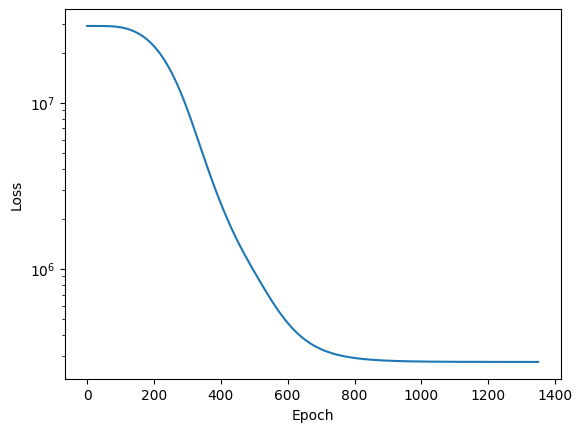

In [ ]:
plt.figure()
plt.plot(loss_history)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

We put the learned VPINN in the form of a function:

In [ ]:
T_sol = lambda xs, ts: trial_ansatz(pinn, xs, ts) * amplitude
gradT_sol = lambda xs, ts: grad_polar(T_sol, xs, ts)
q_sol = lambda xs, ts: -k * gradT_sol(xs, ts)

##Bubnov-Galerkin Solution
For comparison, we also include the results for Bubnov-Galerkin method. That is, when the trial solution lies in the subspace of test functions, $\delta T \in {\rm span}\{\delta T_i\}_{i=1}^{k}$.

In [ ]:
def bilinear_density(T_trial, T_test, x, theta):
  grad_T_trial = grad_polar(T_trial, x, theta)
  grad_T_test = grad_polar(T_test, x, theta)
  # Stiffness density
  dK_dV = k * jnp.sum(grad_T_trial * jnp.conj(grad_T_test))
  # Mass density
  dM_dV = rho * Cp * T_trial(x, theta) * jnp.conj(T_test(x, theta))
  polar_jacobian = (R + x) * h
  return polar_jacobian * dM_dV, polar_jacobian * dK_dV

def linearfunctional_density(T_test, x, theta):
  df_dV = alpha * E * T0 * tangential_strain(x, theta) * jnp.conj(T_test(x, theta))
  polar_jacobian = (R + x) * h
  return polar_jacobian * df_dV

In [ ]:
M_mat = jnp.zeros((N_test_funcs, N_test_funcs))
K_mat = jnp.zeros((N_test_funcs, N_test_funcs))
f_vec = jnp.zeros(N_test_funcs)

for i in range(N_test_funcs):
  v_i = test_func(i+1)
  f_vals = jax.vmap(linearfunctional_density, in_axes=(None,0,0))(v_i, X_GQ[:, 0], X_GQ[:, 1])
  f_i = GQ_jacob * jnp.sum(f_vals * W_GQ)
  f_vec = f_vec.at[i].set(f_i)
  for j in range(i+1):
    v_j = test_func(j+1)
    m_vals, k_vals = jax.vmap(bilinear_density, in_axes=(None,None,0,0))(v_i, v_j, X_GQ[:, 0], X_GQ[:, 1])
    m_ij = jnp.sum(GQ_jacob * m_vals * W_GQ)
    k_ij = jnp.sum(GQ_jacob * k_vals * W_GQ)
    M_mat = M_mat.at[i,j].set(m_ij)
    M_mat = M_mat.at[j,i].set(m_ij)
    K_mat = K_mat.at[i,j].set(k_ij)
    K_mat = K_mat.at[j,i].set(k_ij)

# Solving for the real c_R and imgainary c_I parts of the coefficients
# invK_M = jnp.linalg.solve(K_mat, M_mat) # get K^{-1}*M
# coefs_I = jnp.linalg.solve(K_mat + omega_n**2 * M_mat @ invK_M , omega_n * f_vec)
# coefs_R = omega_n * invK_M @ coefs_I
# coefs = coefs_R + 1j * coefs_I

# Directly solving for the coefficients
coefs = jnp.linalg.solve( 1j * omega_n * M_mat + K_mat, 1j*omega_n * f_vec)

Wrapping the Bubnov-Galerkin solution as a callable function:

In [ ]:
def T_Galerkin(x, theta):
  u = 0.0 + 0.0j
  for i in range(N_test_funcs):
    u += coefs[i] * test_func(i+1)(x, theta)
  return u * amplitude

gradT_Galerkin = lambda xs, ts: grad_polar(T_Galerkin, xs, ts)
q_Galerkin = lambda xs, ts: -k * gradT_Galerkin(xs, ts)

##Results

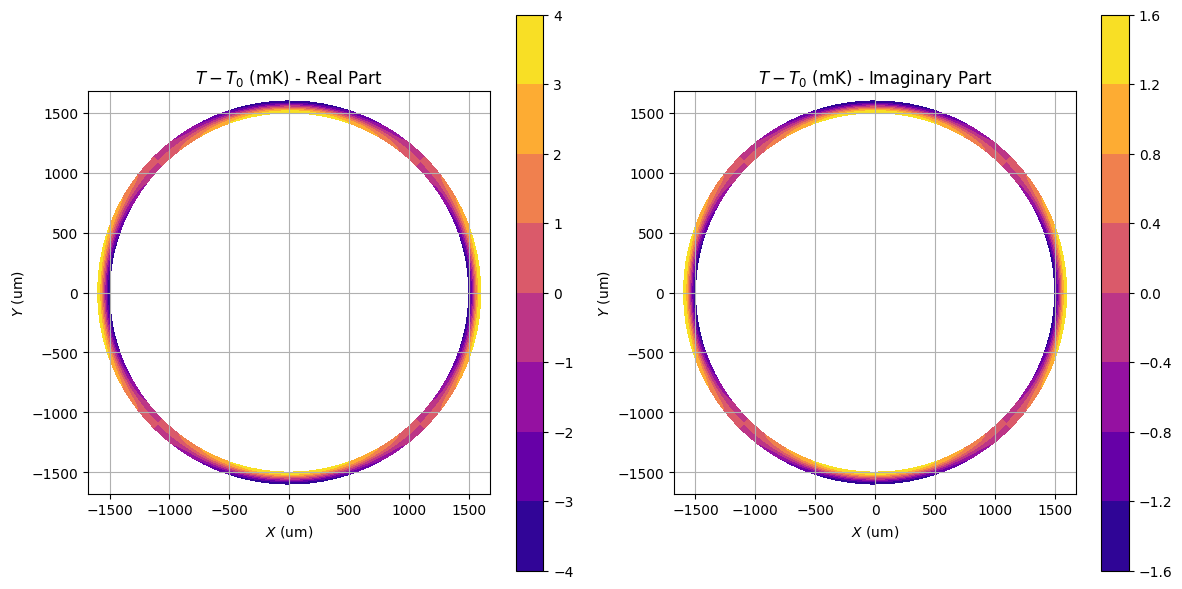

In [ ]:
x_grid = jnp.linspace(x_min, x_max, 100)
r_grid = R + x_grid
theta_grid = jnp.linspace(theta_min, theta_max, 100)
R_grid, Theta_grid = jnp.meshgrid(r_grid, theta_grid)
RTheta_grid = jnp.stack((R_grid.ravel(), Theta_grid.ravel()), axis=1)
X_grid, Y_grid = R_grid * jnp.cos(Theta_grid), R_grid * jnp.sin(Theta_grid)
T_Real = 1e03 * jnp.real(jax.vmap(T_sol, in_axes=(0,0))(RTheta_grid[:,0] - R, RTheta_grid[:,1]))
T_Imag = 1e03 * jnp.imag(jax.vmap(T_sol, in_axes=(0,0))(RTheta_grid[:,0] - R, RTheta_grid[:,1]))
T_Real = T_Real.reshape(X_grid.shape)
T_Imag = T_Imag.reshape(X_grid.shape)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.contourf(X_grid*1e06, Y_grid*1e06, T_Real, cmap='plasma')
plt.xlim(-1.05*r_max*1e06, 1.05*r_max*1e06)
plt.ylim(-1.05*r_max*1e06, 1.05*r_max*1e06)
plt.gca().set_aspect('equal')
plt.grid()
plt.colorbar()
plt.title(r"$T-T_0$ (mK) - Real Part")
plt.xlabel(r"$X$ (um)")
plt.ylabel(r"$Y$ (um)")

plt.subplot(1,2,2)
plt.contourf(X_grid*1e06, Y_grid*1e06, T_Imag, cmap='plasma')
plt.xlim(-1.05*r_max*1e06, 1.05*r_max*1e06)
plt.ylim(-1.05*r_max*1e06, 1.05*r_max*1e06)
plt.gca().set_aspect('equal')
plt.grid()
plt.colorbar()
plt.title(r"$T-T_0$ (mK) - Imaginary Part")
plt.xlabel(r"$X$ (um)")
plt.ylabel(r"$Y$ (um)")
plt.tight_layout()
plt.show()

In [ ]:
print(jnp.max(T_Real))
print(jnp.min(T_Real))
print(jnp.max(T_Imag))
print(jnp.min(T_Imag))

0.07736055
-0.077321604
0.031545497
-0.031529617


Visualizing the temperature at max ($\theta=0$) & min ($\theta = \frac{\pi}{2}$) amplitudes of the mode shape:

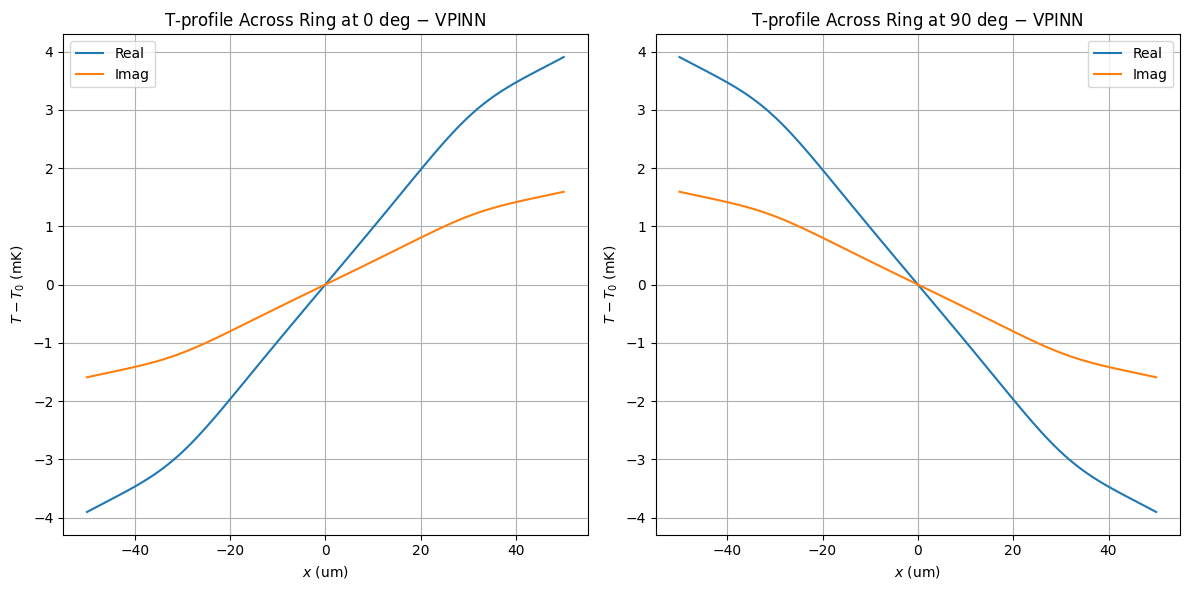

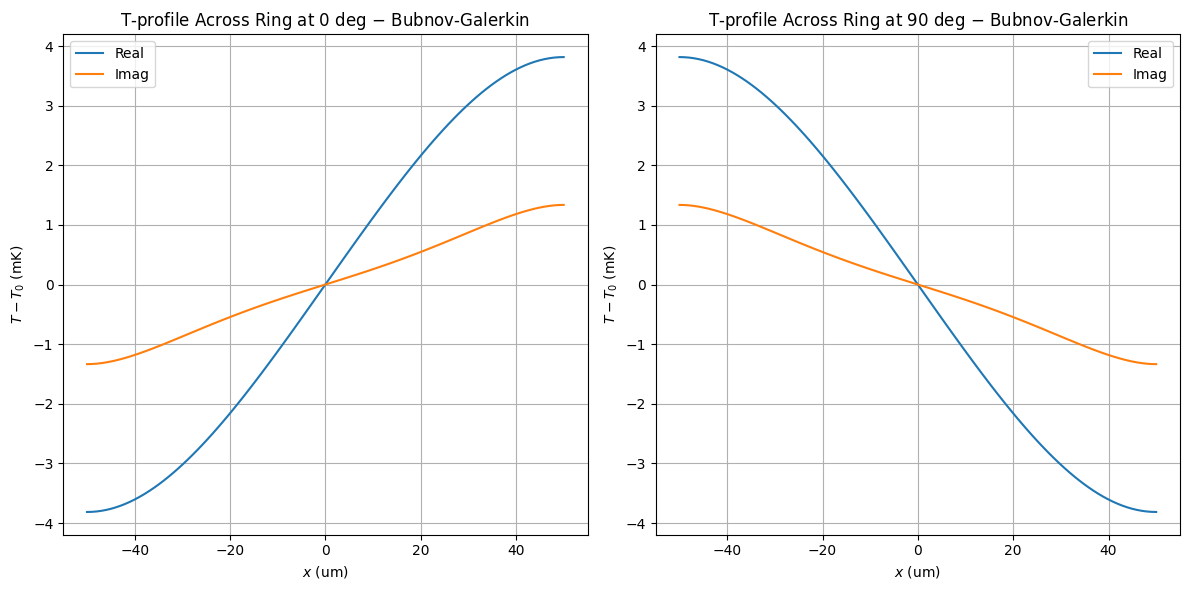

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(x_grid*1e06, 1e03 * jnp.real(jax.vmap(T_sol, in_axes=(0,None))(x_grid, 0.)), label="Real")
plt.plot(x_grid*1e06, 1e03 * jnp.imag(jax.vmap(T_sol, in_axes=(0,None))(x_grid, 0.)), label="Imag")
plt.grid()
plt.legend()
plt.xlabel(r"$x$ (um)")
plt.ylabel(r"$T - T_0$ (mK)")
plt.title(r"T-profile Across Ring at 0 deg $-$ VPINN")

plt.subplot(1,2,2)
plt.plot(x_grid*1e06, 1e03 * jnp.real(jax.vmap(T_sol, in_axes=(0,None))(x_grid, jnp.pi/2)), label="Real")
plt.plot(x_grid*1e06, 1e03 * jnp.imag(jax.vmap(T_sol, in_axes=(0,None))(x_grid, jnp.pi/2)), label="Imag")
plt.grid()
plt.legend()
plt.xlabel(r"$x$ (um)")
plt.ylabel(r"$T - T_0$ (mK)")
plt.title(r"T-profile Across Ring at 90 deg $-$ VPINN")
plt.tight_layout()
plt.show()

#Bubnov-Galerkin solution
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(x_grid*1e06, 1e03 * jnp.real(jax.vmap(T_Galerkin, in_axes=(0,None))(x_grid, 0.)), label="Real")
plt.plot(x_grid*1e06, 1e03 * jnp.imag(jax.vmap(T_Galerkin, in_axes=(0,None))(x_grid, 0.)), label="Imag")
plt.grid()
plt.legend()
plt.xlabel(r"$x$ (um)")
plt.ylabel(r"$T - T_0$ (mK)")
plt.title(r"T-profile Across Ring at 0 deg $-$ Bubnov-Galerkin")

plt.subplot(1,2,2)
plt.plot(x_grid*1e06, 1e03 * jnp.real(jax.vmap(T_Galerkin, in_axes=(0,None))(x_grid, jnp.pi/2)), label="Real")
plt.plot(x_grid*1e06, 1e03 * jnp.imag(jax.vmap(T_Galerkin, in_axes=(0,None))(x_grid, jnp.pi/2)), label="Imag")
plt.grid()
plt.legend()
plt.xlabel(r"$x$ (um)")
plt.ylabel(r"$T - T_0$ (mK)")
plt.title(r"T-profile Across Ring at 90 deg $-$ Bubnov-Galerkin")
plt.tight_layout()
plt.show()

###Thermoelastic Dissipation & Quality Factor
The quality factor is defined as
\begin{align}
Q = \frac{W_{\rm loss}}{2\pi U_{\rm max}}.
\end{align}
Here, $U_{\rm max}=\frac{1}{2}\text{Stiffness}\times\text{Amplitude}^2$ is the maximum strain energy per cycle. $W_{\rm loss}$ is the work loss per cycle due to thermoelastic dissipation and is given by
$$W_{\rm loss} = \int_{0}^{\frac{2\pi}{\omega_n}}\int_{\Omega} -\frac{q.\nabla T}{T_0}\ {\rm d}\Omega\ {\rm d}t$$

In [ ]:
dissipation_density = lambda xs, ts: - 0.5 * jnp.sum(q_sol(xs, ts) * jnp.conj(gradT_sol(xs,ts))) * (R+xs) * h / T0
Dissipation = GQ_jacob * jnp.sum(jax.vmap(dissipation_density)(X_GQ[:,0], X_GQ[:,1]) * W_GQ)
Q_inv = jnp.real(Dissipation) / (0.5 * modal_stiffness * omega_n * amplitude**2)

We repeat the same process for the Bubnov-Galerkin solution:

In [ ]:
dissipation_density_Galerkin = lambda xs, ts: - 0.5 * jnp.sum(q_Galerkin(xs, ts) * jnp.conj(gradT_Galerkin(xs,ts))) * (R+xs) * h / T0
Dissipation_Galerkin = GQ_jacob * jnp.sum(jax.vmap(dissipation_density_Galerkin)(X_GQ[:,0], X_GQ[:,1]) * W_GQ)
Q_inv_Galerkin = jnp.real(Dissipation_Galerkin) / (0.5 * modal_stiffness * omega_n * amplitude**2)

###Analytical Q-factor
We compare our calculated Q-factor with the following analytical model [3]:
\begin{align}
&Q^{-1} = \Delta_E \left(\frac{6}{\zeta^2} - \frac{6}{\zeta^3}\frac{\sin(\zeta)+\sinh(\zeta)}{\cos(\zeta)+\cosh(\zeta)} \right),\\
&\zeta = w \sqrt{ \frac{\omega_n}{2\chi}  }.
\end{align}

In [ ]:
zeta = w * jnp.sqrt(0.5 * omega_n / chi)
Q_inv0 = 6*Delta_E * (1/zeta**2 - (1/zeta**3) * (jnp.sin(zeta)+jnp.sinh(zeta))/(jnp.cos(zeta)+jnp.cosh(zeta)))

In [ ]:
print("Method           | ----------------- Quality Factor (k) ----------------- ")
print("_________________|")
print(f"VPINN            |                       {1e-03/Q_inv:.4f}")
print(f"Bubnov-Galerkin  |                       {1e-03/Q_inv_Galerkin:.4f}")
print(f"Analytical       |                       {1e-03/Q_inv0:.4f}")

Method           | ----------------- Quality Factor (k) ----------------- 
_________________|
VPINN            |                       16.8344
Bubnov-Galerkin  |                       16.7973
Analytical       |                       16.8204


##References
[1] M. Hosseini-Pishrobat and E. Tatar, “Thermal stresses in multiring MEMS gyroscopes: Mathematical modeling with experimental validation,” Journal of Sound and Vibration, vol. 618, p. 119345, Dec. 2025, doi: 10.1016/j.jsv.2025.119345.

[2] R. B. Hetnarski and M. R. Eslami, Thermal Stresses—Advanced Theory and Applications, vol. 158. in Solid Mechanics and Its Applications, vol. 158. Cham: Springer International Publishing, 2019. doi: 10.1007/978-3-030-10436-8.

[3] S. J. Wong, C. H. J. Fox, and S. McWilliam, “Thermoelastic damping of the in-plane vibration of thin silicon rings,” Journal of Sound and Vibration, vol. 293, no. 1, pp. 266–285, May 2006, doi: 10.1016/j.jsv.2005.09.037.

